In [21]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data_path = "../MIRepNet/data/BNCI2014004/X.npy"
label_path = "../MIRepNet/data/BNCI2014004/labels.npy"
data = np.load(data_path)
labels = np.load(label_path)
fs = 250
print(np.shape(data), np.shape(labels))

(1400, 3, 1000) (1400,)


In [ ]:
n_channels = 3
n_samples = 1400
eeg_data_shape = (n_channels, n_samples)

In [12]:
import numpy as np
from scipy.signal import welch

def compute_alpha_welch_3d(eeg_data, fs,
                           alpha_band=(8, 12),
                           nperseg_sec=2,
                           overlap=0.5):
    """
    eeg_data: (n_samples, n_channels, n_timepoints)
    fs: sampling frequency
    """

    n_samples, n_channels, _ = eeg_data.shape

    nperseg = int(nperseg_sec * fs)
    noverlap = int(nperseg * overlap)

    alpha_power = np.zeros((n_samples, n_channels))

    for s in range(n_samples):
        for ch in range(n_channels):

            signal = eeg_data[s, ch]

            freqs, psd = welch(
                signal,
                fs=fs,
                nperseg=nperseg,
                noverlap=noverlap,
                window='hann'
            )

            alpha_mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])

            alpha_power[s, ch] = np.trapz(
                psd[alpha_mask],
                freqs[alpha_mask]
            )

    return alpha_power

In [14]:
alpha_power = compute_alpha_welch_3d(data, fs,
                           alpha_band=(8, 12),
                           nperseg_sec=2,
                           overlap=0.5)

[3.24570284 4.38369429 3.55289186]


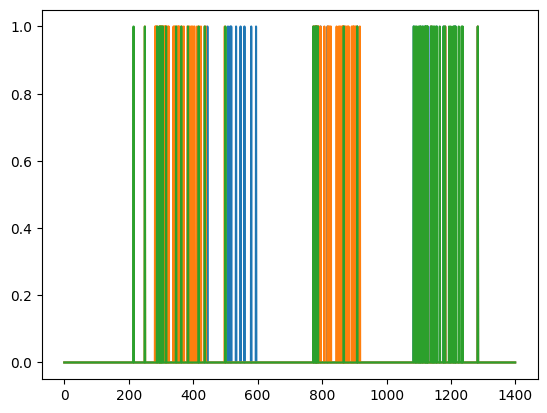

In [23]:
alpha_mean = alpha_power.mean(axis=0)  # mean across trials
alpha_increase = alpha_power > (alpha_power.mean() + 2*alpha_power.std())
print(alpha_mean)
plt.plot(alpha_increase)

In [24]:
def compute_relative_alpha_3d(eeg_data, fs,
                              alpha_band=(8, 12),
                              nperseg_sec=2):

    n_samples, n_channels, _ = eeg_data.shape
    nperseg = int(nperseg_sec * fs)

    rel_alpha = np.zeros((n_samples, n_channels))

    for s in range(n_samples):
        for ch in range(n_channels):

            signal = eeg_data[s, ch]
            freqs, psd = welch(signal, fs=fs, nperseg=nperseg)

            total_power = np.trapz(psd, freqs)

            alpha_mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
            alpha_power = np.trapz(psd[alpha_mask], freqs[alpha_mask])

            rel_alpha[s, ch] = alpha_power / total_power

    return rel_alpha

[0.17965079 0.19230061 0.17406628]


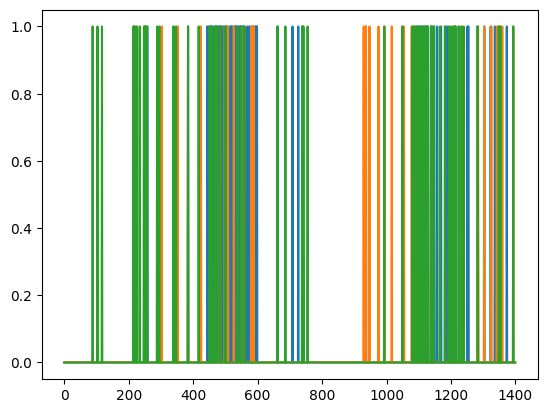

In [25]:
rel_alpha = compute_relative_alpha_3d(data, fs,
                              alpha_band=(8, 12),
                              nperseg_sec=2)

alpha_mean = rel_alpha.mean(axis=0)  # mean across trials
alpha_increase = rel_alpha > (rel_alpha.mean() + 2*rel_alpha.std())
print(alpha_mean)
plt.plot(alpha_increase)